# Ejemplo de análisis espacial: NDVI y cobertura vegetal en Gandoca-Manzanillo

<div style="display: flex; justify-content: flex-start;">
  <a href="https://colab.research.google.com/github/tpb708-programacionsig/2026-i/blob/main/contenidos/iv-procesamiento-datos-geoespaciales/07-ejemplo-analisis-ndvi-gandoca.ipynb">
    <img src="https://img.shields.io/badge/Abrir%20en-Colab-F9AB00?logo=googlecolab&logoColor=white" alt="Abrir en Colab" style="margin: 0;">
  </a>
</div>

## Trabajo previo

### Lecturas

Tenkanen, H., Heikinheimo, V., & Whipp, D. (2024). *Introduction to Python for Geographic Data Analysis*. CRC Press. [https://pythongis.org/](https://pythongis.org/)
\
\
Lovelace, R., Nowosad, J., & Müller, J. (2024). *Geocomputation with Python*. CRC Press. [https://py.geocompx.org/](https://py.geocompx.org/)

### Otros recursos

Documentación oficial de rasterio\
[rasterio documentation](https://rasterio.readthedocs.io/)

  - [Masking a raster using a shapefile](https://rasterio.readthedocs.io/en/stable/topics/masking-by-shapefile.html)
  - [rasterio.features.geometry_mask](https://rasterio.readthedocs.io/en/stable/api/rasterio.features.html#rasterio.features.geometry_mask)

Sistema Nacional de Áreas de Conservación (SINAC)\
[SINAC](https://www.sinac.go.cr/)

Tucker, C. J. (1979). Red and photographic infrared linear combinations for monitoring vegetation. *Remote Sensing of Environment*, 8(2), 127–150. [https://www.sciencedirect.com/science/article/abs/pii/0034425779900130](https://www.sciencedirect.com/science/article/abs/pii/0034425779900130)

Referencia de paletas de colores de matplotlib\
[Colormap reference — matplotlib documentation](https://matplotlib.org/stable/gallery/color/colormap_reference.html)

## Introducción

El **Índice de Vegetación de Diferencia Normalizada** (NDVI, por sus siglas en inglés) es uno de los índices más usados en teledetección para caracterizar la cobertura vegetal. Se calcula a partir de las bandas roja (R) e infrarroja cercana (NIR) de una imagen satelital:

$$
\text{NDVI} = \frac{\text{NIR} - \text{R}}{\text{NIR} + \text{R}}
$$

El NDVI toma valores en el rango $[-1, 1]$. Una clasificación común es:

- $\text{NDVI} < 0$: agua o superficies sin vegetación.
- $0 \le \text{NDVI} < 0.2$: suelo desnudo o vegetación muy escasa.
- $0.2 \le \text{NDVI} < 0.5$: vegetación moderada (pastizales, cultivos).
- $\text{NDVI} \ge 0.5$: vegetación densa (bosques).

Este cuaderno calcula y clasifica el NDVI en el **Refugio Nacional de Vida Silvestre Mixto Gandoca-Manzanillo**, un área protegida del Caribe Sur de Costa Rica que combina bosque, manglar y ecosistemas costero-marinos. El análisis consta de cuatro pasos:

1. Calcular el NDVI a partir de las bandas roja y NIR de toda la imagen.
2. Recortar el NDVI al polígono del refugio.
3. Clasificar los valores de NDVI en categorías de cobertura.
4. Calcular el área de cada categoría dentro del refugio.

## Carga de bibliotecas

In [1]:
# Carga de rasterio
import rasterio

# Módulo de rasterio para graficar datos raster
import rasterio.plot

# Módulo de rasterio para construir máscaras a partir de geometrías
from rasterio.features import geometry_mask

# Carga de geopandas con el alias gpd
import geopandas as gpd

# Carga de pandas con el alias pd
import pandas as pd

# Biblioteca para álgebra lineal
import numpy as np

# Carga de matplotlib y utilidades de color
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

# Carga de la clase WebFeatureService del módulo wfs de owslib
from owslib.wfs import WebFeatureService

# Carga de la clase BytesIO del módulo estándar io
from io import BytesIO

## Carga de datos

### Imagen satelital de Gandoca

La imagen es una **escena Sentinel-2 L2A** del 4 de febrero de 2024 (7.55 % de nubosidad), bajada del catálogo abierto de [Microsoft Planetary Computer](https://planetarycomputer.microsoft.com/). Se recortó al *bounding box* del refugio terrestre y se conservaron únicamente las dos bandas necesarias para calcular el NDVI: la roja (B04) y la infrarroja cercana (B08), ambas con resolución espacial de 10 m. El archivo está alojado en el repositorio del curso.

In [2]:
# Lectura de la imagen satelital
imagen = rasterio.open(
    'https://github.com/tpb708-programacionsig/2026-i/raw/refs/heads/main/datos/sentinel/gandoca-refugio-20240204.tif'
)

print(imagen)
print('Descripciones de las bandas:', imagen.descriptions)

<open DatasetReader name='https://github.com/tpb708-programacionsig/2026-i/raw/refs/heads/main/datos/sentinel/gandoca-refugio-20240204.tif' mode='r'>
Descripciones de las bandas: ('Roja (B04)', 'NIR (B08)')


In [3]:
# Metadatos de la imagen
imagen.meta

{'driver': 'GTiff',
 'dtype': 'uint16',
 'nodata': 0.0,
 'width': 1811,
 'height': 1231,
 'count': 2,
 'crs': CRS.from_wkt('PROJCS["WGS 84 / UTM zone 17N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-81],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32617"]]'),
 'transform': Affine(10.0, 0.0, 312120.0,
        0.0, -10.0, 1066640.0)}

### Refugio Gandoca-Manzanillo (WFS SINAC)

El polígono del refugio se obtiene del servicio WFS del SINAC. Primero listamos las capas disponibles en el servicio.

In [4]:
# Conexión al servicio WFS del SINAC
wfs_url = 'http://geos1pne.sirefor.go.cr/wfs'
wfs_version = '1.1.0'
wfs = WebFeatureService(url=wfs_url, version=wfs_version)

# Lista de las capas disponibles en el servicio WFS
for nombre_capa in wfs.contents:
    print(nombre_capa)

PNE:cobertura_forestal_2021
PNE:cobertura_forestal_2023
PNE:corredoresbiologicos
PNE:patrimonio_natural_del_estado
PNE:registro_nacional_humedales
PNE:areas_silvestres_protegidas
PNE:areas_conservacion


Luego se descarga la capa `PNE:areas_silvestres_protegidas` y se construye un `GeoDataFrame`.

In [5]:
# Obtener la capa de áreas silvestres protegidas
capa = 'PNE:areas_silvestres_protegidas'
respuesta = wfs.getfeature(typename=capa, outputFormat='application/json')

# Leer la respuesta en un GeoDataFrame
asp_gdf = gpd.read_file(BytesIO(respuesta.read()))

# Primeras filas
asp_gdf[['nombre_asp', 'cat_manejo', 'siglas_ac']].head()

,nombre_asp,cat_manejo,siglas_ac
0,Barra del Colorado,Area Marina de Manejo,ACTo
1,Barra del Colorado,Refugio Nacional de Vida Silvestre,ACTo
2,Maquenque,Refugio Nacional de Vida Silvestre,ACAHN
3,Cano Negro,Refugio Nacional de Vida Silvestre,ACAHN
4,Volcan Tenorio,Parque Nacional,ACAT


El refugio Gandoca-Manzanillo es un refugio **mixto**: en la capa del SINAC aparece como **dos polígonos** con el mismo nombre, uno terrestre y otro marino. Como el NDVI no tiene sentido sobre el mar (el agua no tiene vegetación), se conserva únicamente la parte terrestre. La columna `descripcio` distingue ambas porciones.

In [6]:
# Filtrar el refugio Gandoca-Manzanillo y conservar solo la parte terrestre
refugio_gdf = asp_gdf[
    asp_gdf['nombre_asp'].str.contains('Gandoca', case=False, na=False)
    & (asp_gdf['descripcio'] == 'Area terrestre protegida')
]

# Filas resultantes
refugio_gdf[['nombre_asp', 'descripcio', 'area_km2']]

,nombre_asp,descripcio,area_km2
21,Gandoca Manzanillo,Area terrestre protegida,45.646675


El refugio viene en EPSG:5367 (CR05/CRTM05 antiguo). La imagen Sentinel-2 viene en EPSG:32617 (UTM zona 17 N, el sistema nativo de las escenas Sentinel para esta latitud). Para enmascarar el raster con el polígono ambos deben estar en el **mismo CRS**: reproyectamos el polígono al CRS de la imagen.

In [7]:
# Reproyectar el refugio al CRS de la imagen (EPSG:32617, UTM 17 N)
refugio_proj_gdf = refugio_gdf.to_crs(epsg=32617)

# Verificar el nuevo CRS
refugio_proj_gdf.crs

<Projected CRS: EPSG:32617>
Name: WGS 84 / UTM zone 17N
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Between 84°W and 78°W, northern hemisphere between equator and 84°N, onshore and offshore. Bahamas. Ecuador - north of equator. Canada - Nunavut; Ontario; Quebec. Cayman Islands. Colombia. Costa Rica. Cuba. Jamaica. Nicaragua. Panama. United States (USA).
- bounds: (-84.0, 0.0, -78.0, 84.0)
Coordinate Operation:
- name: UTM zone 17N
- method: Transverse Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

## Análisis

### Cálculo del NDVI

El archivo contiene 2 bandas:

- **Banda 1 (Roja, B04)**: ~664 nm. Absorbida por la clorofila → valores bajos sobre vegetación sana.
- **Banda 2 (NIR, B08)**: ~833 nm. Reflejada por la estructura interna de las hojas → valores altos sobre vegetación sana.

El contraste entre ambas es la base del NDVI. Los valores se manejan como enteros sin signo (`uint16`) que representan reflectancia escalada (escala Sentinel-2 L2A). El valor `nodata` es `0` y debe enmascararse antes del cálculo para evitar bordes espurios.

In [8]:
# Lectura de las bandas roja (1) y NIR (2) como float32
red = imagen.read(1).astype('float32')
nir = imagen.read(2).astype('float32')

# Enmascarar nodata (Sentinel-2 L2A usa 0 fuera del área válida)
nodata = imagen.nodata
red[red == nodata] = np.nan
nir[nir == nodata] = np.nan

# Cálculo del NDVI con manejo de la división por cero
with np.errstate(divide='ignore', invalid='ignore'):
    ndvi = (nir - red) / (nir + red)

# Limitar al rango válido
ndvi = np.clip(ndvi, -1, 1)

# Estadísticas básicas
print(f'NDVI mín: {np.nanmin(ndvi):.3f}')
print(f'NDVI máx: {np.nanmax(ndvi):.3f}')
print(f'NDVI medio: {np.nanmean(ndvi):.3f}')

NDVI mín: -0.273
NDVI máx: 0.742
NDVI medio: 0.368


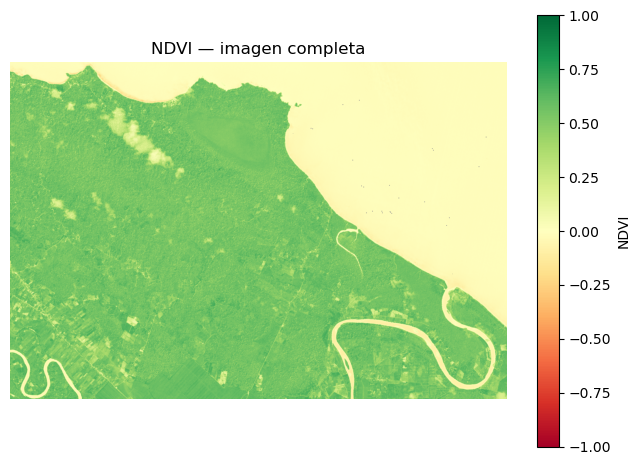

In [9]:
fig, ax = plt.subplots(figsize=(8, 8))
im = ax.imshow(ndvi, cmap='RdYlGn', vmin=-1, vmax=1)
ax.set_title('NDVI — imagen completa')
ax.axis('off')
fig.colorbar(im, ax=ax, label='NDVI', shrink=0.7)
plt.show()

### Recorte del NDVI al refugio

Para limitar el análisis al área del refugio se construye una máscara booleana del mismo tamaño que el raster: `True` en los píxeles que **están dentro** del polígono, `False` en los que **están fuera**. Esto se hace con `rasterio.features.geometry_mask()`, usando la transformación afín del raster para alinear geometría y píxeles.

In [10]:
# Máscara booleana: True donde está dentro del refugio
dentro_refugio = geometry_mask(
    refugio_proj_gdf.geometry,
    transform=imagen.transform,
    out_shape=ndvi.shape,
    invert=True,  # invertir: True dentro, False fuera
)

# Aplicar la máscara al NDVI (fuera del refugio queda como NaN)
ndvi_refugio = np.where(dentro_refugio, ndvi, np.nan)

# Cantidad de píxeles dentro del refugio (con dato válido)
n_validos = int(np.sum(~np.isnan(ndvi_refugio)))
print(f'Píxeles dentro del refugio con dato válido: {n_validos}')
print(f'NDVI medio en el refugio: {np.nanmean(ndvi_refugio):.3f}')

Píxeles dentro del refugio con dato válido: 456447
NDVI medio en el refugio: 0.519


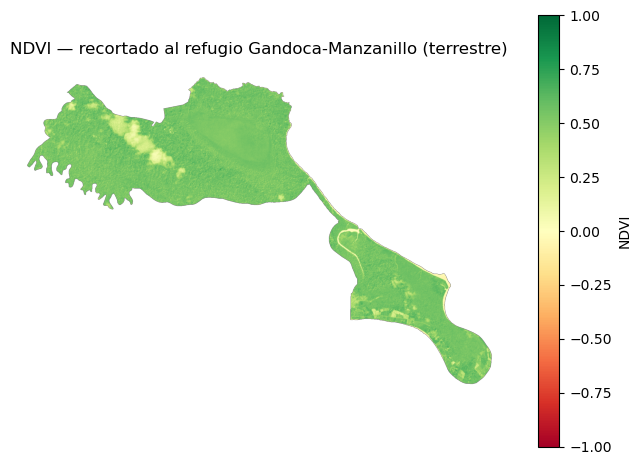

In [11]:
fig, ax = plt.subplots(figsize=(8, 8))
im = ax.imshow(ndvi_refugio, cmap='RdYlGn', vmin=-1, vmax=1)
ax.set_title('NDVI — recortado al refugio Gandoca-Manzanillo (terrestre)')
ax.axis('off')
fig.colorbar(im, ax=ax, label='NDVI', shrink=0.7)
plt.show()

### Clasificación del NDVI por cobertura

Los valores de NDVI se asignan a una de cuatro categorías de cobertura. Los umbrales son una convención común pero pueden ajustarse según el contexto.

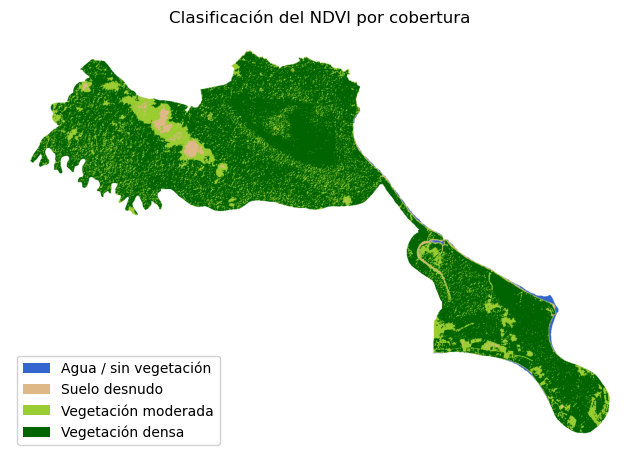

In [12]:
# Umbrales y etiquetas de las categorías
umbrales = [-1, 0, 0.2, 0.5, 1]
etiquetas = [
    'Agua / sin vegetación',
    'Suelo desnudo',
    'Vegetación moderada',
    'Vegetación densa',
]

# Asignar a cada píxel su categoría (1, 2, 3 o 4)
clases = np.digitize(ndvi_refugio, bins=umbrales[1:-1]) + 1

# Los píxeles NaN (fuera del refugio o nodata) quedan en la última
# categoría por defecto; se reasignan a la clase 0 (sin datos).
clases = np.where(np.isnan(ndvi_refugio), 0, clases).astype('uint8')

# Paleta categórica (clase 0 = blanco, las otras 4 con colores)
colores = ['#3366cc', '#deb887', '#9acd32', '#006400']
cmap = ListedColormap(['white'] + colores)
norm = BoundaryNorm([0, 1, 2, 3, 4, 5], cmap.N)

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(clases, cmap=cmap, norm=norm)
ax.set_title('Clasificación del NDVI por cobertura')
ax.axis('off')

# Leyenda
from matplotlib.patches import Patch
handles = [Patch(facecolor=colores[i], label=etiquetas[i]) for i in range(4)]
ax.legend(handles=handles, loc='lower left', framealpha=0.9)
plt.show()

### Estadísticas por categoría

La resolución de la imagen es de 10 m por píxel, así que cada píxel representa $10 \times 10 = 100 \text{ m}^2 = 0.01 \text{ ha}$. El área de cada categoría se obtiene multiplicando el conteo de píxeles por 100 m².

In [13]:
# Resolución del raster (lado del píxel en metros)
res_x, res_y = imagen.res
area_pixel_m2 = res_x * res_y
print(f'Área por píxel: {area_pixel_m2:.1f} m²')

# Conteo de píxeles por categoría (excluyendo la clase 0 = fuera o sin datos)
valores, conteos = np.unique(clases[clases > 0], return_counts=True)

# Tabla resumen
resumen = pd.DataFrame({
    'categoría': [etiquetas[v - 1] for v in valores],
    'píxeles': conteos,
    'área (ha)': conteos * area_pixel_m2 / 10_000,
})
resumen['porcentaje'] = 100 * resumen['píxeles'] / resumen['píxeles'].sum()
resumen = resumen.sort_values('área (ha)', ascending=False).reset_index(drop=True)
resumen

Área por píxel: 100.0 m²


,categoría,píxeles,área (ha),porcentaje
0,Vegetación densa,356091,3560.91,78.013658
1,Vegetación moderada,89299,892.99,19.563936
2,Suelo desnudo,8172,81.72,1.790350
3,Agua / sin vegetación,2885,28.85,0.632056


### Exportar el raster clasificado para QGIS

El arreglo `clases` está en memoria pero todavía no es un archivo raster georreferenciado. Para abrirlo en un SIG de escritorio como [QGIS](https://qgis.org/) hay que escribirlo a un GeoTIFF conservando el CRS y la transformación afín del raster original. Así el archivo se alinea correctamente con otras capas (ortofotos, límites cantonales, áreas protegidas) al abrirse en QGIS.

In [14]:
# Ruta de salida (en el mismo directorio donde corre el cuaderno)
salida = 'ndvi_clases_gandoca.tif'

# Perfil basado en el de la imagen original, ajustado para 1 banda uint8
perfil = imagen.profile.copy()
perfil.update({
    'count': 1,         # una sola banda (la clase)
    'dtype': 'uint8',   # los valores 0..4 caben en un byte
    'nodata': 0,        # la clase 0 (sin datos) se marca como nodata
    'compress': 'lzw',  # compresión sin pérdida
})

with rasterio.open(salida, 'w', **perfil) as dst:
    dst.write(clases, 1)
    dst.set_band_description(1, 'Clase de cobertura (1-4)')
    # Etiquetas como metadatos (visibles desde QGIS → Propiedades → Metadatos)
    dst.update_tags(
        clase_1='Agua / sin vegetación (NDVI < 0)',
        clase_2='Suelo desnudo (0 <= NDVI < 0.2)',
        clase_3='Vegetación moderada (0.2 <= NDVI < 0.5)',
        clase_4='Vegetación densa (NDVI >= 0.5)',
    )

import os
print(f'Archivo guardado: {salida}')
print(f'Tamaño: {os.path.getsize(salida) / 1024:.1f} KB')

Archivo guardado: ndvi_clases_gandoca.tif
Tamaño: 64.0 KB


Para abrir el archivo en QGIS:

- **En Colab**: la siguiente celda dispara la descarga del archivo a su computador (también es posible verlo en el panel lateral de archivos de Colab y descargarlo manualmente).
- **En un ambiente local**: el archivo ya está en el directorio donde se ejecuta el cuaderno; ábralo directamente desde QGIS.

Una vez en QGIS, el raster aparece como una imagen en escala de grises porque los valores son enteros del 1 al 4. Para visualizarlo con la paleta de cobertura, hay que cambiar el estilo: **Propiedades de la capa → Simbología → Tipo de representación: *Paletted/Unique values* → Clasificar**. Luego se pueden asignar manualmente los colores (azul para agua, café para suelo desnudo, verde claro para vegetación moderada y verde oscuro para vegetación densa) y las etiquetas correspondientes a cada valor.

In [15]:
# Disparar la descarga en Colab; en un ambiente local, mostrar la ruta
try:
    from google.colab import files
    files.download(salida)
except ImportError:
    print(f'Entorno local detectado. El archivo está en el directorio '
          f'actual con el nombre: {salida}')

Entorno local detectado. El archivo está en el directorio actual con el nombre: ndvi_clases_gandoca.tif


## Ejercicios

1. Aplique el mismo análisis a otra área silvestre protegida del Caribe (por ejemplo, el Parque Nacional Cahuita). ¿Necesita una imagen satelital distinta? ¿Por qué?

2. Cambie los umbrales de la clasificación del NDVI (por ejemplo, use 5 categorías en lugar de 4) y compare la distribución resultante. ¿Qué efecto tienen los umbrales sobre las conclusiones?